In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.transform import resize

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
)

In [3]:
folder = r"C:\Users\pkwki\OneDrive\Desktop\459 Project\data\fiber_subset"

In [4]:
rows = []

for file in os.listdir(folder):
    if file.endswith(".jpg"):
        name = file.replace(".jpg", "")
        axx, ayy, azz = map(float, name.split(","))

        rows.append({
            "image_file": file,
            "a_xx": axx,
            "a_yy": ayy,
            "a_zz": azz
        })

df_img = pd.DataFrame(rows)

print(df_img.shape)
print(df_img.head())

(1507, 4)
                 image_file    a_xx    a_yy    a_zz
0  0.0030,0.5303,0.4667.jpg  0.0030  0.5303  0.4667
1  0.0031,0.5649,0.4320.jpg  0.0031  0.5649  0.4320
2  0.0037,0.5458,0.4505.jpg  0.0037  0.5458  0.4505
3  0.0037,0.6071,0.3892.jpg  0.0037  0.6071  0.3892
4  0.0038,0.4358,0.5605.jpg  0.0038  0.4358  0.5605


In [5]:
IMG_SIZE = 64

X_img = []
y_img = []

for _, row in df_img.iterrows():
    img_path = os.path.join(folder, row["image_file"])

    img = imread(img_path, as_gray=True)
    img = resize(img, (IMG_SIZE, IMG_SIZE))

    X_img.append(img)
    y_img.append([row["a_xx"], row["a_yy"], row["a_zz"]])

X_img = np.array(X_img)
y_img = np.array(y_img)

# Add channel dimension for CNN
X_img = X_img.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("X shape:", X_img.shape)
print("y shape:", y_img.shape)

X shape: (1507, 64, 64, 1)
y shape: (1507, 3)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_img,
    y_img,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(1205, 64, 64, 1) (302, 64, 64, 1)


In [7]:
model_cnn = Sequential()

model_cnn.add(Conv2D(32, (3, 3), padding="same", activation="relu",
                     input_shape=(IMG_SIZE, IMG_SIZE, 1)))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPool2D((2, 2)))

model_cnn.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPool2D((2, 2)))

model_cnn.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPool2D((2, 2)))

model_cnn.add(Flatten())
model_cnn.add(Dense(128, activation="relu"))
model_cnn.add(Dropout(0.3))

# Regression output: 3 tensor components
model_cnn.add(Dense(3, activation="linear"))

model_cnn.summary()

C:\Users\pkwki\anaconda3\envs\ti64ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,142,659 (4.36 MB)

 Trainable params: 1,142,211 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
model_cnn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [9]:
hist = model_cnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 6.1559 - mae: 0.9585 - val_loss: 26.4354 - val_mae: 5.0414
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1989 - mae: 0.3165 - val_loss: 31.9332 - val_mae: 5.2101
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1457 - mae: 0.2783 - val_loss: 20.2571 - val_mae: 3.5992
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1271 - mae: 0.2600 - val_loss: 4.2234 - val_mae: 1.5697
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1124 - mae: 0.2394 - val_loss: 0.5657 - val_mae: 0.6239
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0983 - mae: 0.2176 - val_loss: 0.1405 - val_mae: 0.3193
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0746 - mae: 0.1746 - val_loss: 0.1123 - val_mae: 0.2903
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0595 - mae: 0.1459 - val_loss: 0.1188 - val_mae: 0.2839
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.

In [10]:
pred_cnn = model_cnn.predict(X_test)

r2_cnn = r2_score(y_test, pred_cnn)
mae_cnn = mean_absolute_error(y_test, pred_cnn)

print("CNN R2:", r2_cnn)
print("CNN MAE:", mae_cnn)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
CNN R2: -1.014744946576134
CNN MAE: 0.09838956359112701


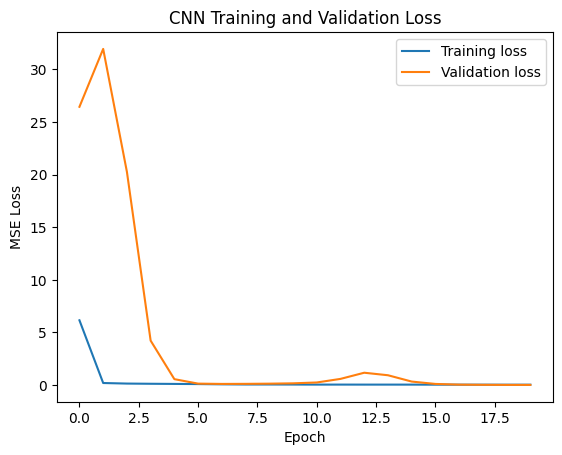

In [11]:
plt.plot(hist.history["loss"], label="Training loss")
plt.plot(hist.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

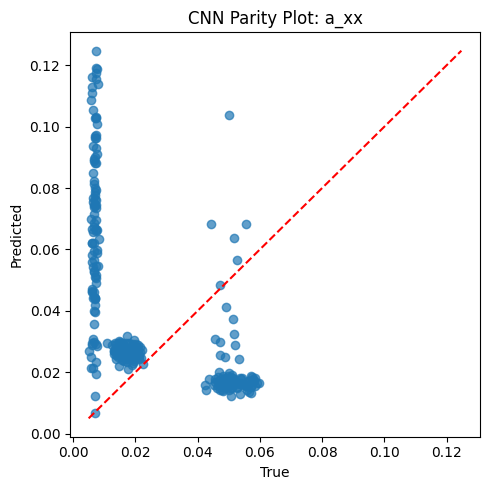

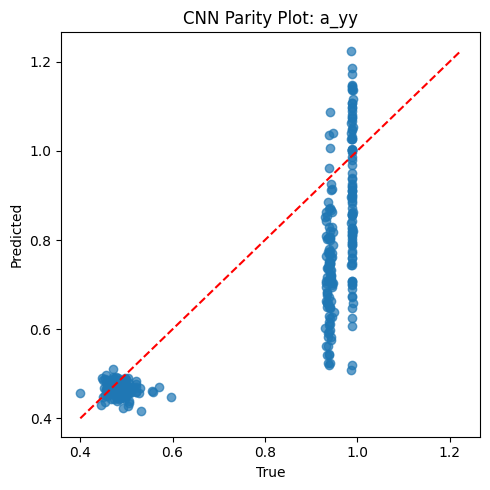

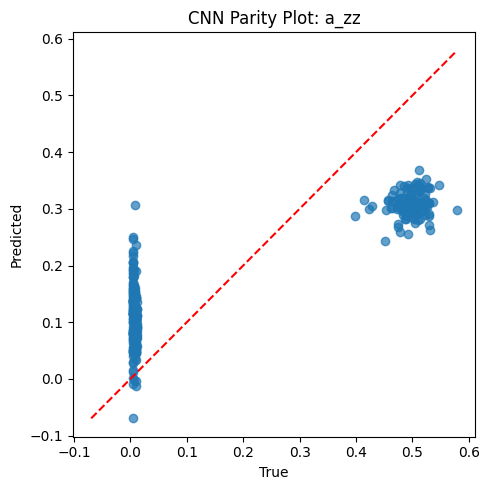

In [12]:
labels = ["a_xx", "a_yy", "a_zz"]

for i in range(3):
    plt.figure(figsize=(5,5))
    plt.scatter(y_test[:, i], pred_cnn[:, i], alpha=0.7)

    min_val = min(y_test[:, i].min(), pred_cnn[:, i].min())
    max_val = max(y_test[:, i].max(), pred_cnn[:, i].max())

    plt.plot([min_val, max_val], [min_val, max_val], "r--")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"CNN Parity Plot: {labels[i]}")
    plt.tight_layout()
    plt.show()